# Verify Slide: Discount Depth vs Loyalty

This notebook verifies the slide chart titled **"Discount depth destroys loyalty"** using the chart codebase and then drills down into how first-order discounts behave across acquisition channels.

## What this notebook checks

1. **Chart verification:** reproduce the chart numbers from `visualizations/05_discount_channel.py` and its source file `EDA/outputs/05_discount_depth_bins.csv`.
2. **Claim verification:** test which parts of the slide are supported, which need softer wording, and what the chart cannot prove.
3. **Channel drilldown:** show how discount usage differs across Direct / Organic, Subscription, Marketplace, and smaller channels.
4. **Customer analytics insights:** separate insights from the headline chart vs insights from the channel drilldown.

## Important language guardrail

The slide title is punchy, but the analysis should be presented as descriptive association, not causality. A safer phrasing is:

> **Deeper first-order discounts are associated with lower repeat and lower LTV.**

In [1]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "EDA" / "outputs"
VIZ_DIR = PROJECT_ROOT / "visualizations"
CHART_CODE = VIZ_DIR / "05_discount_channel.py"
CHART_IMAGE = VIZ_DIR / "charts" / "05a_discount_depth_impact.png"

DATA_SOURCES = {
    "chart_code": CHART_CODE,
    "chart_image": CHART_IMAGE,
    "discount_depth_bins": OUTPUT_DIR / "05_discount_depth_bins.csv",
    "orders": OUTPUT_DIR / "orders.parquet",
    "customers": OUTPUT_DIR / "customers.parquet",
}
for name, path in DATA_SOURCES.items():
    assert path.exists(), f"Missing {name}: {path}"

source_text = "\n".join(str(p) for p in DATA_SOURCES.values()).lower()
for forbidden in [("data", "gold"), ("data", "silver")]:
    assert "/".join(forbidden) not in source_text

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TEAL = "#16B886"
BLUE = "#1F77B4"
ORANGE = "#C76E00"
RED = "#D62728"
NAVY = "#23395B"
SLATE = "#667085"
PURPLE = "#7A5CFA"
GOLD = "#D9A441"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def display_table(df, formats=None, columns=None):
    out = df.copy()
    if columns is not None:
        out = out[columns]
    formats = formats or {}
    for col, fmt in formats.items():
        if col in out.columns:
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else fmt.format(x))
    display(out)

print("Notebook sources:")
for name, path in DATA_SOURCES.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Notebook sources:
- chart_code: visualizations/05_discount_channel.py
- chart_image: visualizations/charts/05a_discount_depth_impact.png
- discount_depth_bins: EDA/outputs/05_discount_depth_bins.csv
- orders: EDA/outputs/orders.parquet
- customers: EDA/outputs/customers.parquet


## 1. Verify The Chart Source

The slide chart maps directly to `visualizations/05_discount_channel.py`, Chart 1. The chart does **not** compute the metric from raw orders directly; it reads `EDA/outputs/05_discount_depth_bins.csv`, which is generated by `EDA/05_channel_discount.py`.

This matters because verification has two layers:

1. Does the slide match the chart code output?
2. Does the chart source table recompute from the EDA customer/order outputs?

In [2]:
chart_code = CHART_CODE.read_text(encoding="utf-8", errors="replace")
chart_block = chart_code.split("# -- Chart 1: Discount depth")[1].split("# -- Chart 2:")[0]

checks = {
    "reads_expected_csv": "05_discount_depth_bins.csv" in chart_block,
    "uses_expected_bin_order": all(x in chart_block for x in ["0% (full price)", "1-5%", "6-10%", "11-20%", "21-30%", "31-50%", "51%+"]),
    "uses_repeat_rate_bar": "repeat_rate" in chart_block and "bar" in chart_block,
    "uses_avg_ltv_line": "avg_ltv" in chart_block and "plot" in chart_block,
    "computes_full_to_51_drop": "drop_pct" in chart_block and "rr_vals[-1]" in chart_block and "rr_vals[0]" in chart_block,
}
source_check = pd.DataFrame([{"check": k, "passed": v} for k, v in checks.items()])
display(source_check)

print("Chart image exists:", CHART_IMAGE.exists())
print("Chart image path:", CHART_IMAGE.relative_to(PROJECT_ROOT))

,check,passed
0,reads_expected_csv,True
1,uses_expected_bin_order,True
2,uses_repeat_rate_bar,True
3,uses_avg_ltv_line,True
4,computes_full_to_51_drop,True


Chart image exists: True
Chart image path: visualizations/charts/05a_discount_depth_impact.png


## 2. Verify The Slide Numbers

The slide shows seven discount-depth bins. The values below are read directly from the chart source CSV and rounded in the same way as the chart code:

- bars = repeat purchase rate
- red line = average LTV
- white text inside bars = customer count

In [3]:
chart_df = pd.read_csv(DATA_SOURCES["discount_depth_bins"])
BIN_ORDER = ["0% (full price)", "1-5%", "6-10%", "11-20%", "21-30%", "31-50%", "51%+"]
BIN_DISPLAY = ["Full price", "1-5% off", "6-10% off", "11-20% off", "21-30% off", "31-50% off", "51%+ off"]
chart_df = chart_df[chart_df["discount_bin"].isin(BIN_ORDER)].set_index("discount_bin").reindex(BIN_ORDER).reset_index()
chart_df["display_bin"] = BIN_DISPLAY
chart_df["repeat_rate_pct"] = chart_df["repeat_rate"] * 100
chart_df["avg_ltv_rounded"] = chart_df["avg_ltv"].round(0).astype(int)

full = chart_df.iloc[0]
last = chart_df.iloc[-1]
drop_raw = (last["repeat_rate"] - full["repeat_rate"]) / full["repeat_rate"]
drop_chart_style = round((round(last["repeat_rate"] * 100, 1) - round(full["repeat_rate"] * 100, 1)) / round(full["repeat_rate"] * 100, 1) * 100)
ltv_drop_last = (last["avg_ltv"] - full["avg_ltv"]) / full["avg_ltv"]

display_table(
    chart_df[["display_bin", "customers", "repeat_rate_pct", "avg_ltv", "avg_ltv_rounded"]],
    {"customers": "{:,.0f}", "repeat_rate_pct": "{:.1f}%", "avg_ltv": "S${:,.0f}", "avg_ltv_rounded": "S${:,.0f}"},
)

display(Markdown(
    f"**Verification:** Full price repeat is {full['repeat_rate']:.1%}; 51%+ off repeat is {last['repeat_rate']:.1%}. "
    f"The chart-style rounded drop is **{drop_chart_style:.0f}%**, matching the slide annotation. "
    f"Average LTV moves from S${full['avg_ltv']:,.0f} to S${last['avg_ltv']:,.0f}, a {ltv_drop_last:.1%} difference."
))

,display_bin,customers,repeat_rate_pct,avg_ltv,avg_ltv_rounded
0,Full price,"9,398",36.4%,S$274,S$274
1,1-5% off,186,17.7%,S$109,S$109
2,6-10% off,395,26.1%,S$135,S$135
3,11-20% off,"1,250",25.5%,S$120,S$120
4,21-30% off,458,25.5%,S$158,S$158
5,31-50% off,"1,189",23.0%,S$150,S$150
6,51%+ off,430,21.9%,S$92,S$92


**Verification:** Full price repeat is 36.4%; 51%+ off repeat is 21.9%. The chart-style rounded drop is **-40%**, matching the slide annotation. Average LTV moves from S$274 to S$92, a -66.4% difference.

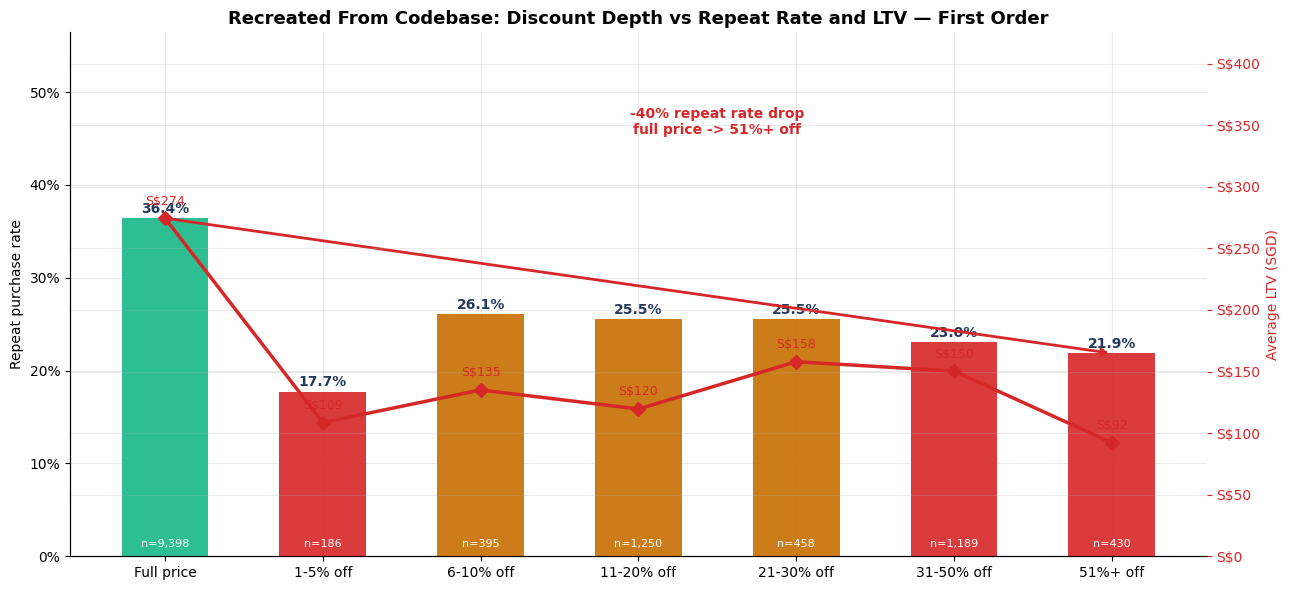

In [4]:
fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(chart_df))
bar_colors = [TEAL] + [ORANGE if r > 24 else RED for r in chart_df["repeat_rate_pct"].iloc[1:]]
bars = ax1.bar(x, chart_df["repeat_rate_pct"], color=bar_colors, width=0.55, alpha=0.90, zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(chart_df["display_bin"], rotation=0)
ax1.set_ylabel("Repeat purchase rate")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_ylim(0, max(chart_df["repeat_rate_pct"]) * 1.55)
ax1.set_title("Recreated From Codebase: Discount Depth vs Repeat Rate and LTV — First Order", fontsize=13, fontweight="bold")
for bar, _, row in zip(bars, x, chart_df.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6, f"{row.repeat_rate_pct:.1f}%", ha="center", fontweight="bold", color=NAVY)
    ax1.text(bar.get_x() + bar.get_width()/2, 1.0, f"n={row.customers:,.0f}", ha="center", color="white", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, chart_df["avg_ltv"], color=RED, marker="D", linewidth=2.5, markersize=7)
ax2.set_ylabel("Average LTV (SGD)", color=RED)
ax2.tick_params(axis="y", colors=RED)
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax2.set_ylim(0, max(chart_df["avg_ltv"]) * 1.55)
for xi, v in enumerate(chart_df["avg_ltv"]):
    ax2.text(xi, v + max(chart_df["avg_ltv"])*0.04, f"S${v:,.0f}", ha="center", color=RED, fontsize=9)

ax1.annotate("", xy=(len(chart_df)-1, chart_df["repeat_rate_pct"].iloc[-1]), xytext=(0, chart_df["repeat_rate_pct"].iloc[0]), arrowprops=dict(arrowstyle="->", color=RED, lw=2))
ax1.text(len(chart_df)/2, max(chart_df["repeat_rate_pct"])*1.25, f"{drop_chart_style:.0f}% repeat rate drop\nfull price -> 51%+ off", color=RED, ha="center", fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Recompute The Source Table From EDA Outputs

The source CSV should match the EDA logic in `EDA/05_channel_discount.py`:

1. Sort orders by `order_date`.
2. Take the first order per customer.
3. Compute `disc_depth = first_disc_amt / first_order_value`.
4. Bin first-order discount depth.
5. Aggregate `customers`, `repeat_rate`, and `avg_ltv` from `customers.parquet`.

Note the denominator: this is **discount as a percentage of the net paid first-order value**, not discount as a percentage of gross-before-discount price. This is why a few first orders can have discount depth above 100% and fall outside the chart bins.

In [5]:
orders = pd.read_parquet(DATA_SOURCES["orders"]).copy()
customers = pd.read_parquet(DATA_SOURCES["customers"]).copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])
for col in ["Price: Total", "Price: Total Discount"]:
    orders[col] = pd.to_numeric(orders[col], errors="coerce").fillna(0)

first_order = (
    orders.sort_values("order_date")
    .groupby("customer_id")
    .first()
    .reset_index()[["customer_id", "channel", "has_discount", "Price: Total Discount", "Price: Total"]]
    .rename(columns={
        "channel": "first_order_channel",
        "has_discount": "first_discounted",
        "Price: Total Discount": "first_disc_amt",
        "Price: Total": "first_order_value",
    })
)

cust_discount = customers.merge(first_order, on="customer_id", how="left")
cust_discount["analysis_channel"] = cust_discount["first_order_channel"].fillna(cust_discount["first_channel"])
cust_discount["disc_depth_codebase"] = (
    cust_discount["first_disc_amt"].fillna(0) / cust_discount["first_order_value"].replace(0, np.nan)
).fillna(0)
cust_discount["gross_before_discount"] = cust_discount["first_order_value"].fillna(0) + cust_discount["first_disc_amt"].fillna(0)
cust_discount["disc_rate_gross"] = np.where(
    cust_discount["gross_before_discount"] > 0,
    cust_discount["first_disc_amt"].fillna(0) / cust_discount["gross_before_discount"],
    0,
)

bins = [-0.001, 0, 0.05, 0.10, 0.20, 0.30, 0.50, 1.01]
labels = BIN_ORDER
cust_discount["discount_bin_recomputed"] = pd.cut(cust_discount["disc_depth_codebase"], bins=bins, labels=labels)

recomputed = (
    cust_discount.groupby("discount_bin_recomputed", observed=True)
    .agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean"))
    .reindex(BIN_ORDER)
    .reset_index()
    .rename(columns={"discount_bin_recomputed": "discount_bin"})
)
comparison = chart_df[["discount_bin", "customers", "repeat_rate", "avg_ltv"]].merge(
    recomputed,
    on="discount_bin",
    suffixes=("_chart_csv", "_recomputed"),
)
for col in ["customers", "repeat_rate", "avg_ltv"]:
    comparison[f"{col}_diff"] = comparison[f"{col}_recomputed"] - comparison[f"{col}_chart_csv"]

display_table(
    comparison,
    {
        "customers_chart_csv": "{:,.0f}", "customers_recomputed": "{:,.0f}", "customers_diff": "{:+,.0f}",
        "repeat_rate_chart_csv": "{:.3%}", "repeat_rate_recomputed": "{:.3%}", "repeat_rate_diff": "{:+.4%}",
        "avg_ltv_chart_csv": "S${:,.2f}", "avg_ltv_recomputed": "S${:,.2f}", "avg_ltv_diff": "S${:+,.2f}",
    },
)

n_total = len(cust_discount)
n_binned = cust_discount["discount_bin_recomputed"].notna().sum()
n_unbinned = n_total - n_binned
n_over_101 = cust_discount["disc_depth_codebase"].gt(1.01).sum()
display(Markdown(
    f"**Recompute check:** the table matches the chart CSV. The chart bins include {n_binned:,} of {n_total:,} customers. "
    f"There are {n_unbinned:,} customers outside the chart bins, mostly cases where first-order discount depth exceeds 101% of net paid value ({n_over_101:,} customers)."
))

,discount_bin,customers_chart_csv,repeat_rate_chart_csv,avg_ltv_chart_csv,customers_recomputed,repeat_rate_recomputed,avg_ltv_recomputed,customers_diff,repeat_rate_diff,avg_ltv_diff
0,0% (full price),"9,398",36.412%,S$274.45,"9,398",36.412%,S$274.45,+0,+0.0000%,S$+0.00
1,1-5%,186,17.742%,S$108.54,186,17.742%,S$108.54,+0,+0.0000%,S$+0.00
2,6-10%,395,26.076%,S$135.05,395,26.076%,S$135.05,+0,+0.0000%,S$+0.00
3,11-20%,"1,250",25.520%,S$119.58,"1,250",25.520%,S$119.58,+0,+0.0000%,S$-0.00
4,21-30%,458,25.546%,S$157.95,458,25.546%,S$157.95,+0,+0.0000%,S$+0.00
5,31-50%,"1,189",23.045%,S$150.38,"1,189",23.045%,S$150.38,+0,+0.0000%,S$+0.00
6,51%+,430,21.860%,S$92.20,430,21.860%,S$92.20,+0,+0.0000%,S$+0.00


**Recompute check:** the table matches the chart CSV. The chart bins include 13,306 of 13,780 customers. There are 474 customers outside the chart bins, mostly cases where first-order discount depth exceeds 101% of net paid value (474 customers).

## 4. Verify The Claim, Not Just The Chart

The chart supports a narrower claim than the slide wording.

- Supported: customers with deeper first-order discount depth show lower repeat rate and lower average LTV in this descriptive view.
- Needs caution: the chart does not prove causality.
- Needs caution: the chart is customer-level, not promotional-campaign-level, so “every promotional campaign” is too broad.
- Needs caution: the chart shows LTV, not profit margin, so “less profitable” is a proxy claim unless margin/COGS data is added.

In [6]:
deep_bins = ["31-50%", "51%+"]
deep = chart_df[chart_df["discount_bin"].isin(deep_bins)].copy()
deep_customers = deep["customers"].sum()
deep_repeat = np.average(deep["repeat_rate"], weights=deep["customers"])
deep_ltv = np.average(deep["avg_ltv"], weights=deep["customers"])
full_repeat = full["repeat_rate"]
full_ltv = full["avg_ltv"]
claim_check = pd.DataFrame([
    {"claim_component": "51%+ off has ~40% lower repeat than full price", "status": "Verified", "evidence": f"{full_repeat:.1%} -> {last['repeat_rate']:.1%}; rounded chart drop = {drop_chart_style:.0f}%"},
    {"claim_component": ">30% off customers are materially less loyal", "status": "Directionally supported", "evidence": f">30% weighted repeat = {deep_repeat:.1%} vs full price = {full_repeat:.1%}"},
    {"claim_component": ">30% off customers are less profitable", "status": "Use softer wording", "evidence": f">30% weighted avg LTV = S${deep_ltv:,.0f} vs full price = S${full_ltv:,.0f}; profit/margin not shown"},
    {"claim_component": "Every promotional campaign using deep discounts acquires weaker cohorts", "status": "Too strong", "evidence": "Chart is first-order customer discount depth, not campaign-level causal evidence"},
])
display(claim_check)

display(Markdown(
    f"**Safer slide wording:** Customers acquired with >30% first-order discounts have **{(deep_repeat/full_repeat - 1):.1%} lower repeat** "
    f"and **{(deep_ltv/full_ltv - 1):.1%} lower average LTV** than full-price first-order customers. "
    "This is an association, not proof that the discount caused lower loyalty."
))

,claim_component,status,evidence
0,51%+ off has ~40% lower repeat than full price,Verified,36.4% -> 21.9%; rounded chart drop = -40%
1,>30% off customers are materially less loyal,Directionally supported,>30% weighted repeat = 22.7% vs full price = 3...
2,>30% off customers are less profitable,Use softer wording,>30% weighted avg LTV = S$135 vs full price = ...
3,Every promotional campaign using deep discount...,Too strong,"Chart is first-order customer discount depth, ..."


**Safer slide wording:** Customers acquired with >30% first-order discounts have **-37.6% lower repeat** and **-50.8% lower average LTV** than full-price first-order customers. This is an association, not proof that the discount caused lower loyalty.

## 5. Channel Drilldown: How Discounts Work Across Channels

Now we drill into whether discount depth behaves the same across channels.

Definitions:

- **First-order discounted:** first order had any discount amount.
- **Deep first-order discount:** codebase discount depth above 30%, using the same denominator as the chart.
- **Gross discount rate:** discount divided by first-order gross-before-discount value. This is easier to interpret commercially and is included alongside the codebase metric.

In [7]:
cust_discount["deep_discount_gt30"] = cust_discount["disc_depth_codebase"].gt(0.30)
cust_discount["first_discounted_amt"] = cust_discount["first_disc_amt"].fillna(0).gt(0)
channel_summary = (
    cust_discount.groupby("analysis_channel")
    .agg(
        customers=("customer_id", "count"),
        pct_first_order_discounted=("first_discounted_amt", "mean"),
        pct_deep_gt30=("deep_discount_gt30", "mean"),
        avg_codebase_discount_depth=("disc_depth_codebase", "mean"),
        avg_gross_discount_rate=("disc_rate_gross", "mean"),
        repeat_rate=("is_repeat", "mean"),
        avg_ltv=("total_revenue", "mean"),
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)
channel_summary["discount_reliance_index"] = (
    0.45 * channel_summary["pct_first_order_discounted"] +
    0.35 * channel_summary["pct_deep_gt30"] +
    0.20 * channel_summary["avg_gross_discount_rate"]
)

display_table(
    channel_summary,
    {
        "customers": "{:,.0f}", "pct_first_order_discounted": "{:.1%}", "pct_deep_gt30": "{:.1%}",
        "avg_codebase_discount_depth": "{:.1%}", "avg_gross_discount_rate": "{:.1%}",
        "repeat_rate": "{:.1%}", "avg_ltv": "S${:,.0f}", "discount_reliance_index": "{:.1%}",
    },
)

,analysis_channel,customers,pct_first_order_discounted,pct_deep_gt30,avg_codebase_discount_depth,avg_gross_discount_rate,repeat_rate,avg_ltv,discount_reliance_index
1,Direct / Organic,"6,920",31.2%,6.8%,6.8%,12.7%,33.5%,S$198,19.0%
6,Subscription,"4,275",27.8%,10.7%,8.8%,8.8%,40.9%,S$343,18.0%
3,Marketplace,"2,126",79.3%,54.4%,61.3%,26.4%,14.4%,S$115,60.0%
5,Paid Social,382,13.6%,1.0%,1.8%,1.5%,19.4%,S$71,6.8%
2,Email,48,70.8%,8.3%,5.8%,48.1%,12.5%,S$50,44.4%
0,Affiliate,26,100.0%,3.8%,11.9%,14.3%,19.2%,S$94,49.2%
4,Paid Search,3,0.0%,0.0%,0.0%,0.0%,33.3%,S$91,0.0%


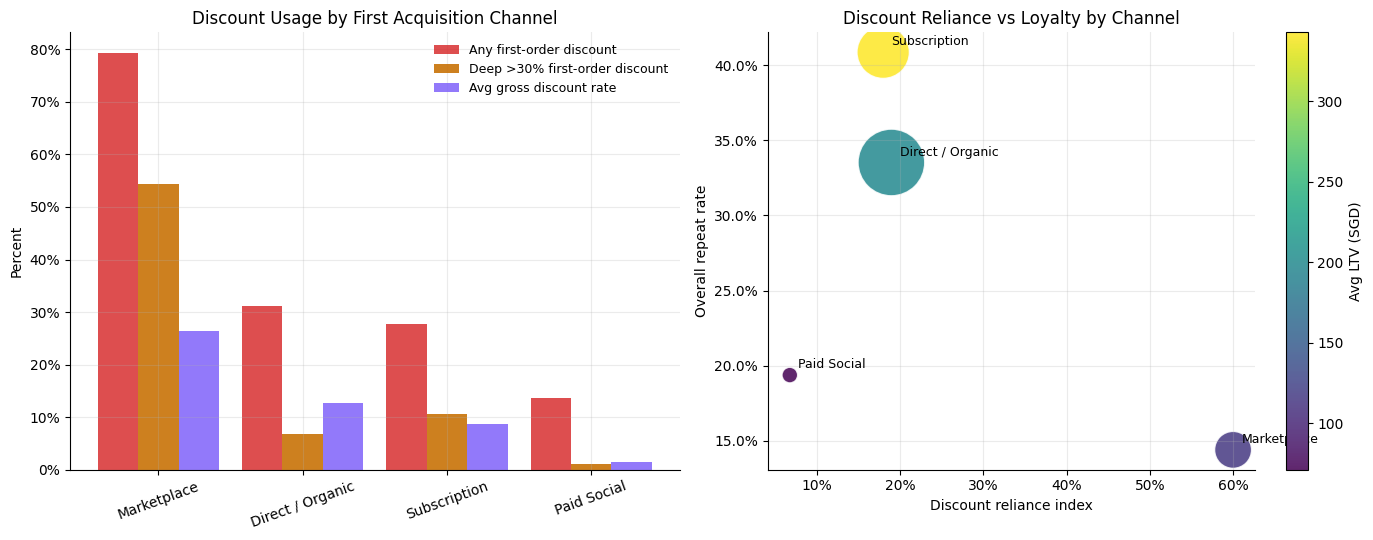

In [8]:
major_channels = channel_summary[channel_summary["customers"].ge(100)]["analysis_channel"].tolist()
plot_ch = channel_summary[channel_summary["analysis_channel"].isin(major_channels)].copy().sort_values("discount_reliance_index", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(plot_ch))
w = 0.28
axes[0].bar(x - w, plot_ch["pct_first_order_discounted"] * 100, width=w, color=RED, alpha=0.82, label="Any first-order discount")
axes[0].bar(x, plot_ch["pct_deep_gt30"] * 100, width=w, color=ORANGE, alpha=0.88, label="Deep >30% first-order discount")
axes[0].bar(x + w, plot_ch["avg_gross_discount_rate"] * 100, width=w, color=PURPLE, alpha=0.82, label="Avg gross discount rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_ch["analysis_channel"], rotation=20)
axes[0].set_ylabel("Percent")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title("Discount Usage by First Acquisition Channel")
axes[0].legend(frameon=False, fontsize=9)

sc = axes[1].scatter(
    plot_ch["discount_reliance_index"] * 100,
    plot_ch["repeat_rate"] * 100,
    s=np.maximum(plot_ch["customers"], 30) / 3,
    c=plot_ch["avg_ltv"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="white",
)
for _, row in plot_ch.iterrows():
    axes[1].annotate(row["analysis_channel"], (row["discount_reliance_index"] * 100, row["repeat_rate"] * 100), textcoords="offset points", xytext=(6, 5), fontsize=9)
axes[1].set_xlabel("Discount reliance index")
axes[1].set_ylabel("Overall repeat rate")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title("Discount Reliance vs Loyalty by Channel")
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label("Avg LTV (SGD)")
fig.tight_layout()
plt.show()

## 6. Within-Channel Drilldown: Deep vs Non-Deep First Discounts

This table compares deep-discount starts against all other first-order starts within each channel. This helps answer whether deep discounting behaves similarly across channels.

Small-channel rows should be read cautiously because sample sizes are limited.

In [9]:
channel_deep = (
    cust_discount.groupby(["analysis_channel", "deep_discount_gt30"])
    .agg(
        customers=("customer_id", "count"),
        repeat_rate=("is_repeat", "mean"),
        avg_ltv=("total_revenue", "mean"),
        avg_gross_discount_rate=("disc_rate_gross", "mean"),
        avg_codebase_discount_depth=("disc_depth_codebase", "mean"),
    )
    .reset_index()
)
channel_deep["discount_group"] = np.where(channel_deep["deep_discount_gt30"], ">30% first-order discount", "<=30% or full price")

display_table(
    channel_deep.sort_values(["analysis_channel", "deep_discount_gt30"]),
    {
        "customers": "{:,.0f}", "repeat_rate": "{:.1%}", "avg_ltv": "S${:,.0f}",
        "avg_gross_discount_rate": "{:.1%}", "avg_codebase_discount_depth": "{:.1%}",
    },
    columns=["analysis_channel", "discount_group", "customers", "repeat_rate", "avg_ltv", "avg_gross_discount_rate", "avg_codebase_discount_depth"],
)

wide = channel_deep.pivot(index="analysis_channel", columns="deep_discount_gt30", values=["customers", "repeat_rate", "avg_ltv"]).copy()
# Flatten safely for channels that have both groups.
comparison_rows = []
for ch in sorted(cust_discount["analysis_channel"].dropna().unique()):
    sub = channel_deep[channel_deep["analysis_channel"].eq(ch)].set_index("deep_discount_gt30")
    if True in sub.index and False in sub.index:
        nondeep = sub.loc[False]
        deep_row = sub.loc[True]
        comparison_rows.append({
            "analysis_channel": ch,
            "nondeep_customers": nondeep["customers"],
            "deep_customers": deep_row["customers"],
            "repeat_delta_deep_minus_nondeep_pp": (deep_row["repeat_rate"] - nondeep["repeat_rate"]) * 100,
            "ltv_delta_deep_minus_nondeep": deep_row["avg_ltv"] - nondeep["avg_ltv"],
        })
channel_deep_compare = pd.DataFrame(comparison_rows).sort_values("deep_customers", ascending=False)
display_table(
    channel_deep_compare,
    {
        "nondeep_customers": "{:,.0f}", "deep_customers": "{:,.0f}",
        "repeat_delta_deep_minus_nondeep_pp": "{:+.1f} pp", "ltv_delta_deep_minus_nondeep": "S${:+,.0f}",
    },
)

,analysis_channel,discount_group,customers,repeat_rate,avg_ltv,avg_gross_discount_rate,avg_codebase_discount_depth
0,Affiliate,<=30% or full price,25,20.0%,S$93,13.8%,11.0%
1,Affiliate,>30% first-order discount,1,0.0%,S$129,25.8%,34.7%
2,Direct / Organic,<=30% or full price,"6,449",34.1%,S$204,11.0%,2.4%
3,Direct / Organic,>30% first-order discount,471,25.7%,S$116,36.3%,67.4%
4,Email,<=30% or full price,44,11.4%,S$41,49.7%,2.2%
5,Email,>30% first-order discount,4,25.0%,S$141,30.3%,44.8%
6,Marketplace,<=30% or full price,969,11.0%,S$136,8.7%,9.2%
7,Marketplace,>30% first-order discount,"1,157",17.2%,S$98,41.1%,105.0%
8,Paid Search,<=30% or full price,3,33.3%,S$91,0.0%,0.0%
9,Paid Social,<=30% or full price,378,19.0%,S$71,1.3%,1.5%


,analysis_channel,nondeep_customers,deep_customers,repeat_delta_deep_minus_nondeep_pp,ltv_delta_deep_minus_nondeep
3,Marketplace,969,"1,157",+6.2 pp,S$-39
1,Direct / Organic,"6,449",471,-8.4 pp,S$-88
5,Subscription,"3,819",456,-10.9 pp,S$-213
2,Email,44,4,+13.6 pp,S$+100
4,Paid Social,378,4,+31.0 pp,S$+60
0,Affiliate,25,1,-20.0 pp,S$+36


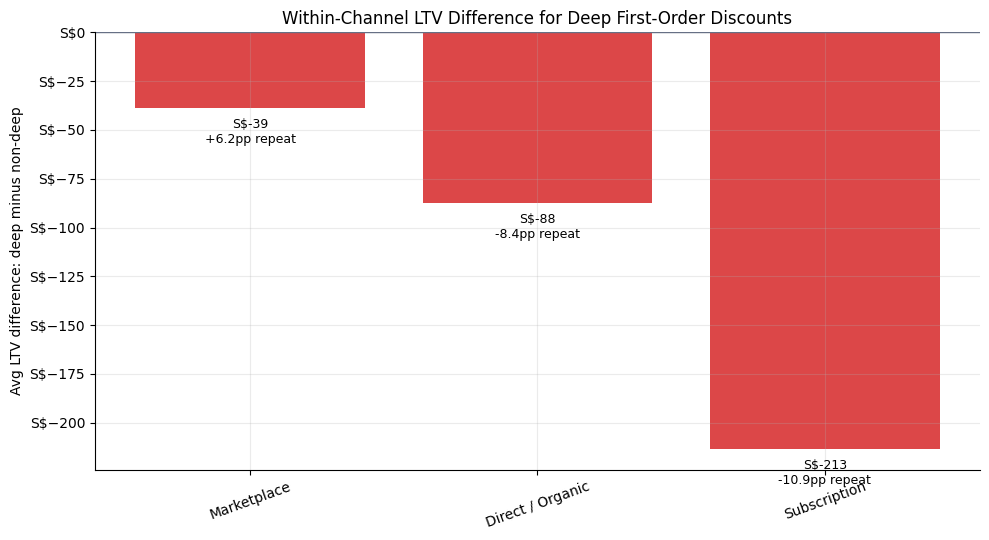

In [10]:
plot_compare = channel_deep_compare[channel_deep_compare["deep_customers"].ge(20)].copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(plot_compare))
colors = [RED if v < 0 else TEAL for v in plot_compare["ltv_delta_deep_minus_nondeep"]]
ax.bar(x, plot_compare["ltv_delta_deep_minus_nondeep"], color=colors, alpha=0.85)
ax.axhline(0, color=SLATE, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_compare["analysis_channel"], rotation=20)
ax.set_ylabel("Avg LTV difference: deep minus non-deep")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax.set_title("Within-Channel LTV Difference for Deep First-Order Discounts")
for xi, row in enumerate(plot_compare.itertuples()):
    ax.text(xi, row.ltv_delta_deep_minus_nondeep + (5 if row.ltv_delta_deep_minus_nondeep >= 0 else -5), f"S${row.ltv_delta_deep_minus_nondeep:+,.0f}\n{row.repeat_delta_deep_minus_nondeep_pp:+.1f}pp repeat", ha="center", va="bottom" if row.ltv_delta_deep_minus_nondeep >= 0 else "top", fontsize=9)
fig.tight_layout()
plt.show()

## 7. Customer Analytics Insights From Point 1: The Slide Chart

These insights come from the headline discount-depth chart only.

1. **First-order discount depth is a meaningful quality segment.** Full-price first-order customers have the strongest observed loyalty and LTV profile.
2. **The 51%+ discount band verifies the slide annotation.** Repeat falls from 36.4% for full-price starts to 21.9% for 51%+ starts, which is a rounded 40% drop.
3. **The LTV signal is even sharper than the repeat signal.** Average LTV falls from about S$274 for full-price starts to about S$92 for 51%+ starts.
4. **Deep discounting should be treated as a payback-risk flag.** Customers acquired at >30% first-order discount have materially lower repeat and lower average LTV than full-price starts.
5. **But the chart does not prove campaign-level causality.** It is a customer-level segmentation chart, so the slide should not say every campaign “creates” weaker customers.
6. **Profitability needs softer wording.** The chart supports lower LTV, not direct margin/profit. If you want to say “less profitable,” add margin, COGS, or contribution profit data.

### Recommended wording for the slide

> Customers acquired through deeper first-order discounts show weaker repeat behavior and lower LTV. Deep discounts appear to buy volume at the expense of customer quality.

## 8. Customer Analytics Insights From Point 2: Channel Discount Drilldown

These insights come from the channel drilldown, not the headline chart alone.

1. **Discounts are not channel-neutral.** Marketplace has the highest first-order discount exposure and the highest deep-discount share among major channels.
2. **Marketplace is the main discount-reliance concern.** It combines high discount reliance with low repeat and low LTV in the Shopify-visible data.
3. **Subscription is still high-quality, but deep discounts weaken its economics.** Subscription overall has the strongest LTV/repeat profile, but the deep-discount subgroup has much lower average LTV than non-deep Subscription starts.
4. **Direct / Organic is the scalable owned-channel base.** It has moderate discount usage and better quality than Marketplace, but deep Direct / Organic starts show lower repeat and lower LTV than non-deep starts.
5. **Marketplace behaves differently within-channel.** Deep-discount Marketplace starts have lower LTV than non-deep starts, but repeat is not lower in this cut. This likely reflects channel mechanics, marketplace sync visibility, and customer mix rather than a clean loyalty improvement.
6. **Small channels are directional only.** Paid Social, Email, Affiliate, and Paid Search have small or recent samples, so they should be tracked, not over-interpreted.

### Recommended channel-management implication

- Use **full-price repeat** and **year-1 LTV** as quality guardrails for every acquisition channel.
- Require stricter payback rules for channels with high deep-discount share.
- Separate Marketplace reporting from owned-site reporting because repeat visibility and customer behavior are structurally different.

## 9. Slide Verification Verdict

| Slide element | Verdict | Recommended action |
|---|---|---|
| Chart values | Verified from codebase source CSV and recomputed from EDA outputs. | Keep chart. |
| “-40% repeat rate drop full price -> 51%+ off” | Verified using chart-style rounded repeat rates. | Keep annotation. |
| “Deep discounts (>30% off) are materially less loyal” | Directionally supported. | Keep, but phrase as “associated with lower repeat.” |
| “Less profitable over time” | Not directly proven by this chart; LTV is a proxy, not profit. | Say “lower LTV” unless margin data is added. |
| “Every promotional campaign...” | Too broad; chart is customer-level, not campaign-level. | Replace with “customers acquired through deep first-order discounts...” |
| “Destroys loyalty” | Too causal for the evidence. | Use “discount depth is associated with weaker loyalty.” |

## Final Presentation Gist

**The slide is directionally right but should be softened. The evidence verifies that deeper first-order discounts are associated with lower repeat and lower LTV. The channel drilldown shows the issue is concentrated in certain acquisition contexts, especially Marketplace, while Subscription and Direct / Organic still carry stronger quality but need discount guardrails.**

In [11]:
for name, path in DATA_SOURCES.items():
    lowered = str(path).lower()
    for forbidden in [("data", "gold"), ("data", "silver")]:
        assert "/".join(forbidden) not in lowered, path
print("Source-path guardrail passed: no forbidden prepared data paths configured.")

Source-path guardrail passed: no forbidden prepared data paths configured.
